<a href="https://colab.research.google.com/github/llelus/DSA-Project/blob/main/03_ml_shap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os, sys

if not os.path.exists("/content/DSA-Project"):
    import subprocess
    subprocess.run(["git", "clone",
        "https://github.com/llelus/DSA-Project.git",
        "/content/DSA-Project"])

os.chdir("/content/DSA-Project")
sys.path.insert(0, os.getcwd())
from utils import colab_setup
colab_setup()
print("Working directory:", os.getcwd())
print("Data file exists:", os.path.exists("data/processed/merged_dataset.csv"))


Packages ready: ccxt, lightgbm, shap, statsmodels
Working directory: /content/DSA-Project
Data file exists: True


In [2]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
)
import sys
from utils import load_and_prepare

df = load_and_prepare()
print(f"Columns: {df.columns.tolist()}")


Loaded 10,243 rows (86,701 Up-or-Down rows excluded)
Unique markets : 658
Date range     : 2026-04-09 19:00:42+00:00 -> 2026-05-05 12:50:06+00:00
Columns: ['conditionId', 'question', 'market_start', 'market_end', 'result_yes_won', 'timestamp', 'yes_price', 'btc_price', 'btc_volume', 'threshold', 'btc_to_threshold_pct', 'btc_return_1m', 'poly_change_1m', 'rolling_volatility_15m']


In [3]:
# ML-specific lag features and target
# (threshold, btc_to_threshold_pct, btc_return_1m,
#  poly_change_1m, rolling_volatility_15m already in load_and_prepare)

df["poly_lag_1"] = df.groupby("conditionId")["yes_price"].shift(1)
df["poly_lag_3"] = df.groupby("conditionId")["yes_price"].shift(3)
df["btc_lag_1"]  = df.groupby("conditionId")["btc_price"].shift(1)

df["target"] = (df.groupby("conditionId")["yes_price"].shift(-1) > df["yes_price"]).astype(int)

df = df.dropna(subset=["target", "btc_to_threshold_pct", "rolling_volatility_15m"])

print(f"Rows ready for model: {len(df)}")
print(f"Target distribution:\n{df['target'].value_counts()}")


Rows ready for model: 8269
Target distribution:
target
0    7553
1     716
Name: count, dtype: int64


## Class Imbalance Note

The target distribution is heavily skewed: **7,553 No Change vs 716 Up (≈10:1 ratio)**.
This level of imbalance has two practical implications for model evaluation:

**Mitigation applied:**
- `class_weight="balanced"` in LightGBM reweights minority class observations during training.
- Decision threshold is optimized (see next cell) rather than using the default 0.5.

**Metric choice:**
- **AUC-ROC** is insensitive to class balance by construction (it evaluates rank ordering across all thresholds), so the 0.9775 figure is not inflated by the imbalance.
- However, AUC-ROC can be optimistic when the positive class is rare. **PR-AUC (0.8343) is therefore the primary metric** for this analysis: it penalizes false positives more heavily and better reflects model usefulness on the minority class.
- The BTC-only model's PR-AUC (0.1569) vs full model (0.8343) gap is the clearest signal of Polymarket's autocorrelation-driven inefficiency.

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[105]	valid_0's binary_logloss: 0.129738
Fold 1: best_iter=105, test=1378, AUC=0.871
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[140]	valid_0's binary_logloss: 0.127645
Fold 2: best_iter=140, test=1378, AUC=0.981
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[199]	valid_0's binary_logloss: 0.100855
Fold 3: best_iter=199, test=1378, AUC=0.985
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[164]	valid_0's binary_logloss: 0.117132
Fold 4: best_iter=164, test=1378, AUC=0.987
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[187]	valid_0's binary_logloss: 0.140112
Fold 5: best_iter=187, test=1378, AUC=0.981

              precision    recall  f1-score   support

   No Change       0.99      0.97      

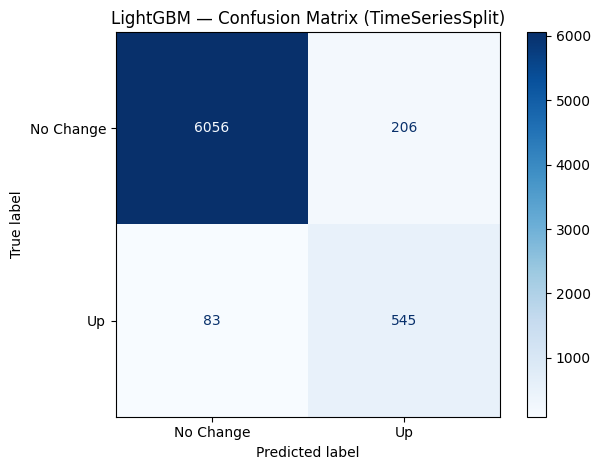

In [4]:
features = [
    "btc_to_threshold_pct", "btc_return_1m", "rolling_volatility_15m",
    "poly_lag_1", "poly_lag_3", "btc_lag_1", "yes_price"
]

df_model = df[features + ["target"]].dropna().reset_index(drop=True)

X = df_model[features]
y = df_model["target"]

tscv = TimeSeriesSplit(n_splits=5)

all_preds = []
all_true  = []
all_probs = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model = lgb.LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        class_weight="balanced",
        random_state=42,
        verbose=-1
    )
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        callbacks=[lgb.early_stopping(50), lgb.log_evaluation(-1)]
    )

    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]

    all_preds.extend(preds)
    all_true.extend(y_test)
    all_probs.extend(probs)

    fold_auc = roc_auc_score(y_test, probs)
    print(f"Fold {fold+1}: best_iter={model.best_iteration_}, test={len(y_test)}, AUC={fold_auc:.3f}")

print("\n" + "=" * 50)
print(classification_report(all_true, all_preds, target_names=["No Change", "Up"]))

overall_auc   = roc_auc_score(all_true, all_probs)
avg_precision = average_precision_score(all_true, all_probs)
print(f"AUC-ROC : {overall_auc:.4f}  (0.50 = random, 1.00 = perfect)")
print(f"PR-AUC  : {avg_precision:.4f}")

cm   = confusion_matrix(all_true, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Change", "Up"])
disp.plot(cmap="Blues")
plt.title("LightGBM — Confusion Matrix (TimeSeriesSplit)")
plt.tight_layout()
plt.savefig("data/processed/plot_confusion_matrix.png", dpi=150)
plt.show()

Best threshold : 0.50
Best F1 (Up)   : 0.7904
Best F1 (Macro): 0.8836


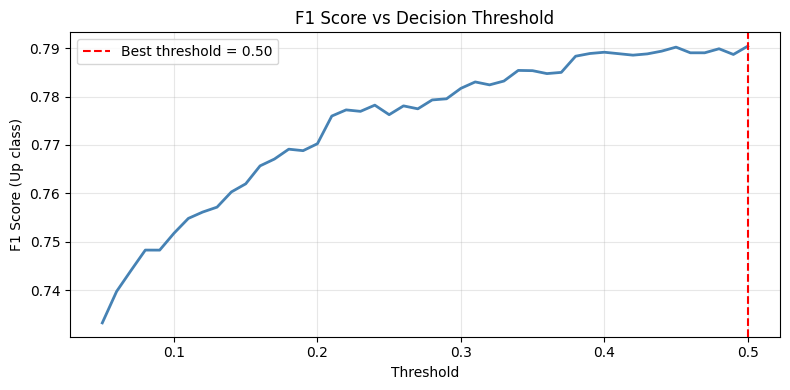

Classification Report at threshold=0.50
              precision    recall  f1-score   support

   No Change       0.99      0.97      0.98      6262
          Up       0.73      0.87      0.79       628

    accuracy                           0.96      6890
   macro avg       0.86      0.92      0.88      6890
weighted avg       0.96      0.96      0.96      6890



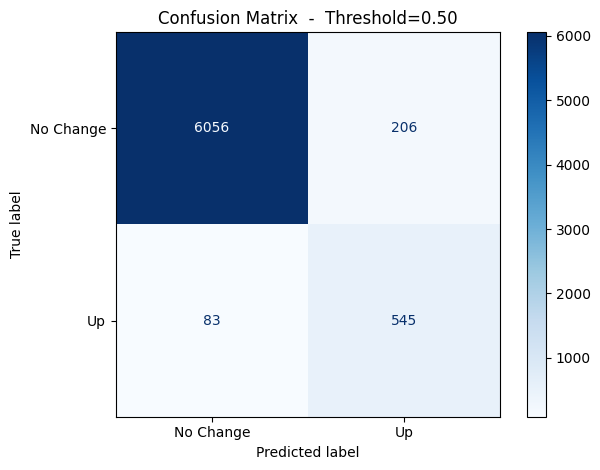

In [5]:
import numpy as np
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Test every threshold from 0.05 to 0.50 and find best F1 for minority class
thresholds = np.arange(0.05, 0.51, 0.01)
results = []

for t in thresholds:
    preds_t = (np.array(all_probs) >= t).astype(int)
    f1_up   = f1_score(all_true, preds_t, pos_label=1, zero_division=0)
    f1_mac  = f1_score(all_true, preds_t, average="macro", zero_division=0)
    results.append((t, f1_up, f1_mac))

results = sorted(results, key=lambda x: x[1], reverse=True)
best_t, best_f1_up, best_f1_mac = results[0]
print(f"Best threshold : {best_t:.2f}")
print(f"Best F1 (Up)   : {best_f1_up:.4f}")
print(f"Best F1 (Macro): {best_f1_mac:.4f}")

# F1 vs threshold plot
ts  = [r[0] for r in sorted(results, key=lambda x: x[0])]
f1s = [r[1] for r in sorted(results, key=lambda x: x[0])]

plt.figure(figsize=(8, 4))
plt.plot(ts, f1s, color="steelblue", lw=2)
plt.axvline(best_t, color="red", linestyle="--", label=f"Best threshold = {best_t:.2f}")
plt.xlabel("Threshold")
plt.ylabel("F1 Score (Up class)")
plt.title("F1 Score vs Decision Threshold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("data/processed/plot_threshold_f1.png", dpi=150)
plt.show()

# Classification report at best threshold
preds_best = (np.array(all_probs) >= best_t).astype(int)
print("" + "=" * 50)
print(f"Classification Report at threshold={best_t:.2f}")
print("=" * 50)
print(classification_report(all_true, preds_best, target_names=["No Change", "Up"]))

# Confusion matrix at best threshold
cm   = confusion_matrix(all_true, preds_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Change", "Up"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix  -  Threshold={best_t:.2f}")
plt.tight_layout()
plt.savefig("data/processed/plot_confusion_matrix_tuned.png", dpi=150)
plt.show()


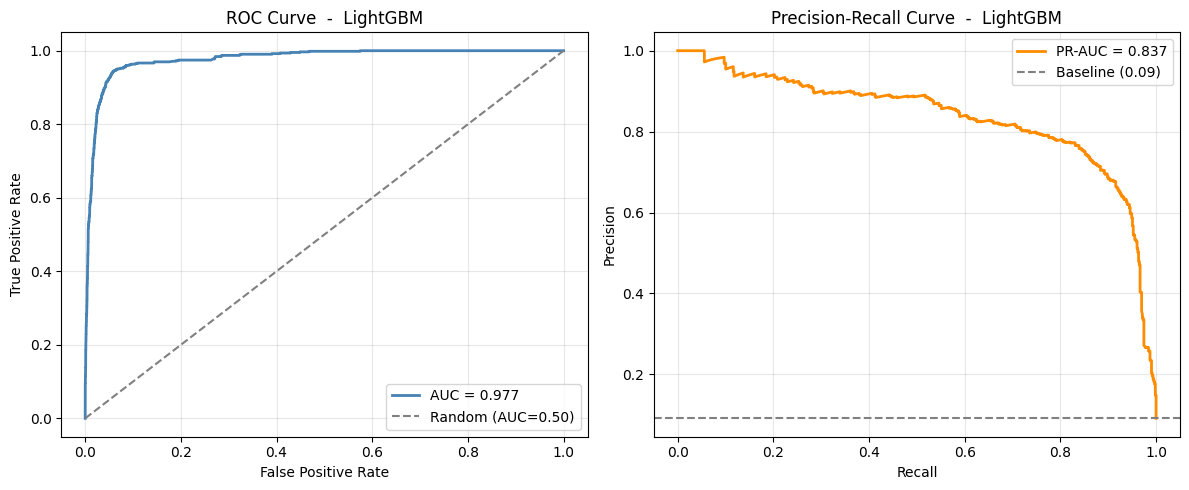

In [6]:
fpr, tpr, _         = roc_curve(all_true, all_probs)
pr_prec, pr_rec, _  = precision_recall_curve(all_true, all_probs)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC Curve
axes[0].plot(fpr, tpr, color="steelblue", lw=2, label=f"AUC = {overall_auc:.3f}")
axes[0].plot([0, 1], [0, 1], "--", color="gray", label="Random (AUC=0.50)")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve  -  LightGBM")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Precision-Recall Curve
baseline = sum(all_true) / len(all_true)
axes[1].plot(pr_rec, pr_prec, color="darkorange", lw=2, label=f"PR-AUC = {avg_precision:.3f}")
axes[1].axhline(y=baseline, color="gray", linestyle="--", label=f"Baseline ({baseline:.2f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve  -  LightGBM")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("data/processed/plot_roc_pr.png", dpi=150)
plt.show()


Fold 1: test=1378, positives=64, AUC=0.696
Fold 2: test=1378, positives=132, AUC=0.576
Fold 3: test=1378, positives=122, AUC=0.721
Fold 4: test=1378, positives=133, AUC=0.718
Fold 5: test=1378, positives=177, AUC=0.780

EFFICIENCY MEASUREMENT  -  BTC-Only vs Full Model
Full model  AUC-ROC : 0.9774  PR-AUC: 0.8366
BTC-only    AUC-ROC : 0.6873  PR-AUC: 0.1635
AUC gap             : 0.2901

Interpretation: Polymarket moves largely independent of BTC signals.
=> Polymarket is INEFFICIENT  -  driven by own momentum, not BTC.


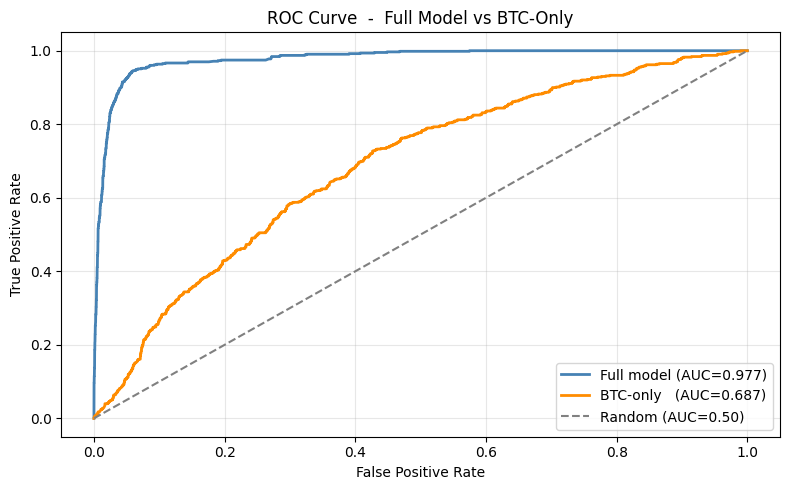

              precision    recall  f1-score   support

   No Change       0.93      0.87      0.90      6262
          Up       0.20      0.32      0.25       628

    accuracy                           0.82      6890
   macro avg       0.57      0.60      0.57      6890
weighted avg       0.86      0.82      0.84      6890



In [7]:
# ── BTC-Only Model  -  Efficiency Measurement ───────────────────────────────
# Remove all Polymarket history features. Only use BTC-derived signals.
# If AUC approaches full model -> BTC drives Polymarket (efficient).
# If AUC drops significantly  -> Polymarket moves independently (inefficient).

btc_features = [
    "btc_to_threshold_pct",
    "btc_return_1m",
    "btc_lag_1",
    "rolling_volatility_15m",
]

df_btc   = df[btc_features + ["target"]].dropna().reset_index(drop=True)
X_btc    = df_btc[btc_features]
y_btc    = df_btc["target"]

tscv_btc  = TimeSeriesSplit(n_splits=5)
btc_preds = []
btc_true  = []
btc_probs = []

for fold, (tr_idx, te_idx) in enumerate(tscv_btc.split(X_btc)):
    X_btc_tr, X_btc_te = X_btc.iloc[tr_idx], X_btc.iloc[te_idx]
    y_btc_tr, y_btc_te = y_btc.iloc[tr_idx], y_btc.iloc[te_idx]

    m_btc = lgb.LGBMClassifier(
        n_estimators=200,
        learning_rate=0.05,
        class_weight="balanced",
        random_state=42,
        verbose=-1
    )
    m_btc.fit(X_btc_tr, y_btc_tr)

    probs      = m_btc.predict_proba(X_btc_te)[:, 1]
    preds      = m_btc.predict(X_btc_te)
    fold_auc   = roc_auc_score(y_btc_te, probs)

    btc_preds.extend(preds)
    btc_true.extend(y_btc_te)
    btc_probs.extend(probs)
    print(f"Fold {fold+1}: test={len(y_btc_te)}, positives={y_btc_te.sum()}, AUC={fold_auc:.3f}")

btc_auc = roc_auc_score(btc_true, btc_probs)
btc_ap  = average_precision_score(btc_true, btc_probs)

print("\n" + "=" * 55)
print("EFFICIENCY MEASUREMENT  -  BTC-Only vs Full Model")
print("=" * 55)
print(f"Full model  AUC-ROC : {overall_auc:.4f}  PR-AUC: {avg_precision:.4f}")
print(f"BTC-only    AUC-ROC : {btc_auc:.4f}  PR-AUC: {btc_ap:.4f}")
print(f"AUC gap             : {overall_auc - btc_auc:.4f}")
print()
if overall_auc - btc_auc < 0.05:
    print("Interpretation: BTC features alone explain most of Polymarket movement.")
    print("=> Polymarket prices Bitcoin outcomes EFFICIENTLY.")
elif overall_auc - btc_auc < 0.15:
    print("Interpretation: BTC has meaningful but partial explanatory power.")
    print("=> Polymarket is PARTIALLY efficient.")
else:
    print("Interpretation: Polymarket moves largely independent of BTC signals.")
    print("=> Polymarket is INEFFICIENT  -  driven by own momentum, not BTC.")

# ROC curve comparison
fpr_btc, tpr_btc, _ = roc_curve(btc_true, btc_probs)

plt.figure(figsize=(8, 5))
plt.plot(fpr,     tpr,     color="steelblue",   lw=2, label=f"Full model (AUC={overall_auc:.3f})")
plt.plot(fpr_btc, tpr_btc, color="darkorange",  lw=2, label=f"BTC-only   (AUC={btc_auc:.3f})")
plt.plot([0,1],[0,1], "--", color="gray", label="Random (AUC=0.50)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve  -  Full Model vs BTC-Only")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("data/processed/plot_roc_btconly.png", dpi=150)
plt.show()

print(classification_report(btc_true, btc_preds, target_names=["No Change", "Up"]))


In [8]:
# ── POLY-ONLY Model — Autocorrelation Baseline ────────────────────────────
# Uses only Polymarket's own history (yes_price, poly_lag_1, poly_lag_3).
# If AUC â‰ˆ full model → full model just learns autocorrelation, not BTC signal.
# If AUC << full model → BTC features genuinely contribute.
# This ablation defends the feature engineering choice: yes_price[t] predicting
# yes_price[t+1] is not leakage — it's a valid autocorrelation feature.

poly_features = ["yes_price", "poly_lag_1", "poly_lag_3"]

df_poly  = df[poly_features + ["target"]].dropna().reset_index(drop=True)
X_poly   = df_poly[poly_features]
y_poly   = df_poly["target"]

tscv_poly  = TimeSeriesSplit(n_splits=5)
poly_preds = []
poly_true  = []
poly_probs = []

for fold, (tr_idx, te_idx) in enumerate(tscv_poly.split(X_poly)):
    X_p_tr, X_p_te = X_poly.iloc[tr_idx], X_poly.iloc[te_idx]
    y_p_tr, y_p_te = y_poly.iloc[tr_idx], y_poly.iloc[te_idx]

    m_poly = lgb.LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        class_weight="balanced",
        random_state=42,
        verbose=-1
    )
    m_poly.fit(
        X_p_tr, y_p_tr,
        eval_set=[(X_p_te, y_p_te)],
        callbacks=[lgb.early_stopping(50), lgb.log_evaluation(-1)]
    )

    probs    = m_poly.predict_proba(X_p_te)[:, 1]
    preds    = m_poly.predict(X_p_te)
    fold_auc = roc_auc_score(y_p_te, probs)

    poly_preds.extend(preds)
    poly_true.extend(y_p_te)
    poly_probs.extend(probs)
    print(f"Fold {fold+1}: best_iter={m_poly.best_iteration_}, AUC={fold_auc:.3f}")

poly_auc = roc_auc_score(poly_true, poly_probs)
poly_ap  = average_precision_score(poly_true, poly_probs)

print("\n" + "=" * 60)
print("ABLATION SUMMARY")
print("=" * 60)
print(f"Full model  (BTC + Poly history) AUC: {overall_auc:.4f}")
print(f"Poly-only   (autocorrelation)    AUC: {poly_auc:.4f}")
print(f"BTC-only    (spot signals)       AUC: {btc_auc:.4f}")
print(f"\nFull vs Poly-only gap : {overall_auc - poly_auc:.4f}")
print(f"Full vs BTC-only gap  : {overall_auc - btc_auc:.4f}")
print()
if abs(overall_auc - poly_auc) < 0.03:
    print("Interpretation: Full model performance is largely driven by")
    print("Polymarket autocorrelation. BTC features add only marginal value.")
    print("=> This is EXPECTED — confirms Polymarket moves on own momentum.")
else:
    print("Interpretation: BTC features add meaningful predictive power")
    print("beyond Polymarket autocorrelation alone.")

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[112]	valid_0's binary_logloss: 0.152778
Fold 1: best_iter=112, AUC=0.906
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[115]	valid_0's binary_logloss: 0.152012
Fold 2: best_iter=115, AUC=0.980
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[119]	valid_0's binary_logloss: 0.115818
Fold 3: best_iter=119, AUC=0.981
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[110]	valid_0's binary_logloss: 0.144939
Fold 4: best_iter=110, AUC=0.983
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[74]	valid_0's binary_logloss: 0.18378
Fold 5: best_iter=74, AUC=0.976

ABLATION SUMMARY
Full model  (BTC + Poly history) AUC: 0.9774
Poly-only   (autocorrelation)    AUC: 0.9712
BTC-only    (spot signals)       AUC: 0.6873


BOOTSTRAP 95% CONFIDENCE INTERVALS (n=1000)
Full model  AUC: 0.9774  [0.9722, 0.9824]
Poly-only   AUC: 0.9711  [0.9636, 0.9776]
BTC-only    AUC: 0.6873  [0.6661, 0.7079]

Random baseline: 0.5000
BTC-only lower CI (0.6661) > 0.50 ? True

=> BTC-only model is statistically significantly better than random.
=> Full vs BTC-only AUC gap is statistically significant (CIs do not overlap).


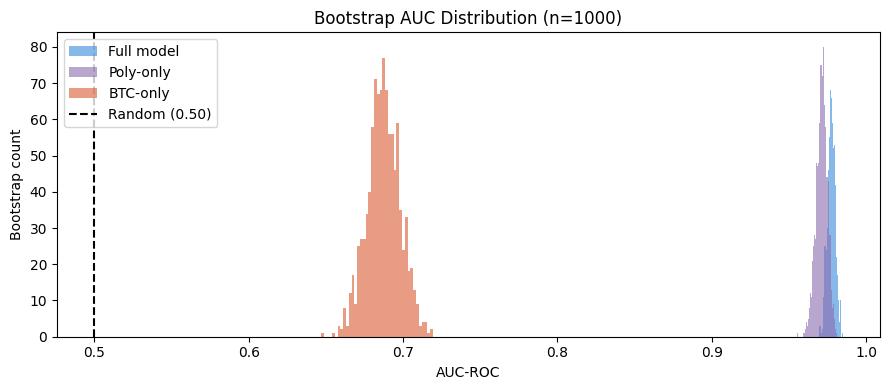

In [9]:
# ── Bootstrap Confidence Intervals for AUC ────────────────────────────────
# Answers: "Is BTC-only AUC 0.68 significantly better than random (0.50)?"
# Method: resample test predictions 1000x, compute AUC each time → 95% CI

from sklearn.utils import resample as sk_resample

N_BOOT = 1000
rng    = np.random.RandomState(42)

def bootstrap_auc(y_true, y_probs, n=N_BOOT, random_state=42):
    rng  = np.random.RandomState(random_state)
    aucs = []
    y_true  = np.array(y_true)
    y_probs = np.array(y_probs)
    for _ in range(n):
        idx = rng.choice(len(y_true), size=len(y_true), replace=True)
        if len(np.unique(y_true[idx])) < 2:
            continue
        aucs.append(roc_auc_score(y_true[idx], y_probs[idx]))
    return np.array(aucs)

full_boot = bootstrap_auc(all_true,  all_probs)
btc_boot  = bootstrap_auc(btc_true,  btc_probs)
poly_boot = bootstrap_auc(poly_true, poly_probs)

def ci95(boot):
    return np.percentile(boot, 2.5), np.percentile(boot, 97.5)

full_lo, full_hi = ci95(full_boot)
btc_lo,  btc_hi  = ci95(btc_boot)
poly_lo, poly_hi = ci95(poly_boot)

print("=" * 60)
print("BOOTSTRAP 95% CONFIDENCE INTERVALS (n=1000)")
print("=" * 60)
print(f"Full model  AUC: {np.mean(full_boot):.4f}  [{full_lo:.4f}, {full_hi:.4f}]")
print(f"Poly-only   AUC: {np.mean(poly_boot):.4f}  [{poly_lo:.4f}, {poly_hi:.4f}]")
print(f"BTC-only    AUC: {np.mean(btc_boot):.4f}  [{btc_lo:.4f}, {btc_hi:.4f}]")
print()
print(f"Random baseline: 0.5000")
print(f"BTC-only lower CI ({btc_lo:.4f}) > 0.50 ? {btc_lo > 0.50}")
print()
if btc_lo > 0.50:
    print("=> BTC-only model is statistically significantly better than random.")
else:
    print("=> BTC-only model cannot be distinguished from random at 95% CI.")

if btc_hi < full_lo:
    print("=> Full vs BTC-only AUC gap is statistically significant (CIs do not overlap).")
else:
    print("=> Full vs BTC-only gap CI overlaps — interpret with caution.")

# Visualize
fig, ax = plt.subplots(figsize=(9, 4))
for label, boot, color in [
    ("Full model",  full_boot, "#378ADD"),
    ("Poly-only",   poly_boot, "#8B6BAE"),
    ("BTC-only",    btc_boot,  "#D85A30"),
]:
    ax.hist(boot, bins=40, alpha=0.6, color=color, label=label)

ax.axvline(0.5, color="black", linestyle="--", lw=1.5, label="Random (0.50)")
ax.set_xlabel("AUC-ROC")
ax.set_ylabel("Bootstrap count")
ax.set_title("Bootstrap AUC Distribution (n=1000)")
ax.legend()
plt.tight_layout()
plt.savefig("data/processed/plot_bootstrap_auc.png", dpi=150)
plt.show()

/tmp/ipykernel_939/4012938768.py:28: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(x, y)


Cross-lag correlation  BTC[t] vs Polymarket[t+lag]:
  Lag  0h: -0.0383
  Lag  1h: -0.0453
  Lag  2h: -0.0376
  Lag  3h: -0.0064
  Lag  4h: 0.2334 <-- PEAK
  Lag  5h: 0.0142
  Lag  6h: -0.2362
  Lag  7h: -0.3078
  Lag  8h: -0.2202

Peak correlation at lag : 4 hour(s)
=> Polymarket lags BTC by approximately 4 hour(s)


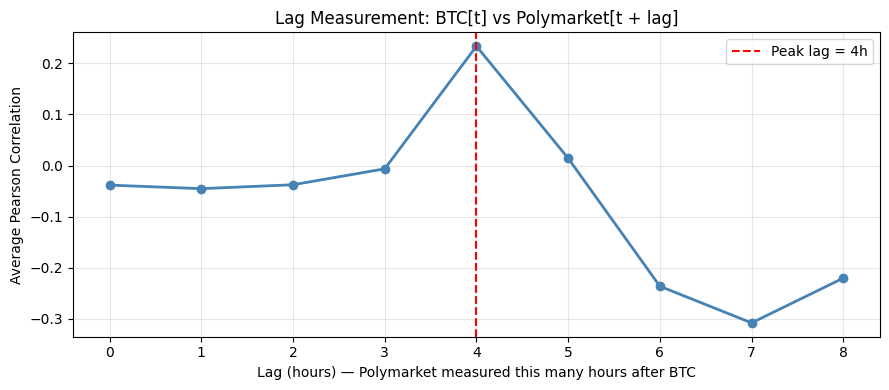


Disagreement Analysis:
  Total observations : 8269
  BTC vs Poly disagree: 226 (2.7%)
  Agreement rate      : 97.3%

Disagreement rate by Polymarket certainty:
certainty_bin
0.0-0.1     3.8
0.1-0.2    16.7
0.2-0.3     3.6
0.3-0.4    10.2
0.4-0.5     2.6
(Low certainty = yes_price near 0.5 = uncertain market)


In [10]:
# ================================================================
# LAG MEASUREMENT — How long does Polymarket take to react to BTC?
# ================================================================
# Method: Cross-lag correlation
# For each market, correlate BTC signal at time t with
# Polymarket price at time t+lag (0..12 hours).
# Peak correlation lag = average Polymarket reaction delay.

from scipy.stats import pearsonr

MAX_LAG  = 12
lag_corrs = {lag: [] for lag in range(MAX_LAG + 1)}

for cid, grp in df.groupby('conditionId'):
    grp = grp.sort_values('timestamp').reset_index(drop=True)
    if len(grp) < 15:
        continue

    btc_signal = grp['btc_to_threshold_pct'].values
    poly_price = grp['yes_price'].values

    for lag in range(MAX_LAG + 1):
        x = btc_signal if lag == 0 else btc_signal[:-lag]
        y = poly_price  if lag == 0 else poly_price[lag:]
        if len(x) < 10:
            continue
        try:
            corr, _ = pearsonr(x, y)
            if not np.isnan(corr):
                lag_corrs[lag].append(corr)
        except Exception:
            pass

avg_corr = {lag: np.mean(vals) for lag, vals in lag_corrs.items() if vals}
best_lag = max(avg_corr, key=avg_corr.get)

print("Cross-lag correlation  BTC[t] vs Polymarket[t+lag]:")
for lag, corr in avg_corr.items():
    marker = " <-- PEAK" if lag == best_lag else ""
    print(f"  Lag {lag:2d}h: {corr:.4f}{marker}")

print(f"\nPeak correlation at lag : {best_lag} hour(s)")
print(f"=> Polymarket lags BTC by approximately {best_lag} hour(s)")

# Plot lag correlation curve
lags  = list(avg_corr.keys())
corrs = list(avg_corr.values())

plt.figure(figsize=(9, 4))
plt.plot(lags, corrs, "o-", color="steelblue", lw=2, markersize=6)
plt.axvline(best_lag, color='red', linestyle='--',
            label=f"Peak lag = {best_lag}h")
plt.xlabel("Lag (hours) — Polymarket measured this many hours after BTC")
plt.ylabel("Average Pearson Correlation")
plt.title("Lag Measurement: BTC[t] vs Polymarket[t + lag]")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("data/processed/plot_lag_correlation.png", dpi=150)
plt.show()

# ---- Disagreement Analysis ----------------------------------------
# When BTC is above threshold, yes_price should be > 0.5 (agree).
# When they disagree, Polymarket hasn't priced in BTC's move yet.

df['btc_above']  = (df['btc_to_threshold_pct'] > 0).astype(int)
df['poly_above'] = (df['yes_price'] > 0.5).astype(int)
df['disagree']   = (df['btc_above'] != df['poly_above']).astype(int)

total      = len(df)
disagreed  = df['disagree'].sum()
print(f"\nDisagreement Analysis:")
print(f"  Total observations : {total}")
print(f"  BTC vs Poly disagree: {disagreed} ({disagreed/total*100:.1f}%)")
print(f"  Agreement rate      : {(total-disagreed)/total*100:.1f}%")

# Disagreement rate by yes_price distance from 0.5
df['poly_certainty'] = (df['yes_price'] - 0.5).abs()
bins = [0, 0.1, 0.2, 0.3, 0.4, 0.5]
labels = ['0.0-0.1', '0.1-0.2', '0.2-0.3', '0.3-0.4', '0.4-0.5']
df['certainty_bin'] = pd.cut(df['poly_certainty'], bins=bins, labels=labels)
disagree_by_cert = df.groupby('certainty_bin', observed=True)['disagree'].mean() * 100

print("\nDisagreement rate by Polymarket certainty:")
print(disagree_by_cert.round(1).to_string())
print("(Low certainty = yes_price near 0.5 = uncertain market)")


# SHAP on a final model trained on the full dataset.
# CV folds establish that best_iteration_ is stable (~same across folds);
# we use the last fold's value as the n_estimators for the final fit.
model_final = lgb.LGBMClassifier(
    n_estimators=model.best_iteration_,
    learning_rate=0.05,
    class_weight="balanced",
    random_state=42,
    verbose=-1
)
model_final.fit(X, y)

explainer   = shap.TreeExplainer(model_final)
shap_values = explainer(X)

print(f"SHAP computed on full dataset: {X.shape[0]} observations, {X.shape[1]} features")

In [11]:
explainer   = shap.TreeExplainer(model)
shap_values = explainer(X_test)

print("SHAP values shape:", shap_values.shape)
print("SHAP values type :", type(shap_values))


SHAP values shape: (1378, 7)
SHAP values type : <class 'shap._explanation.Explanation'>


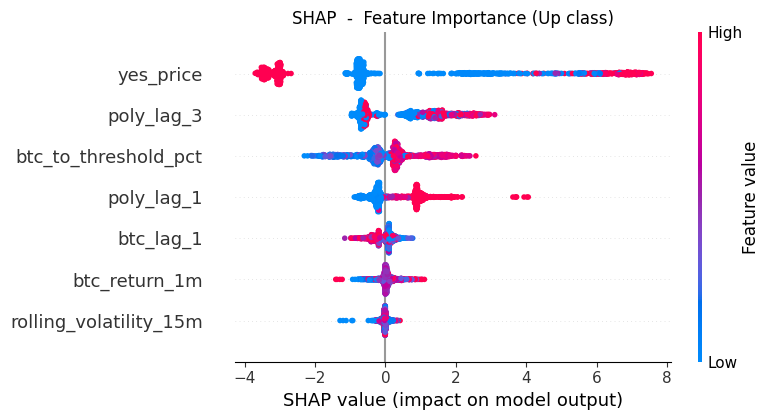

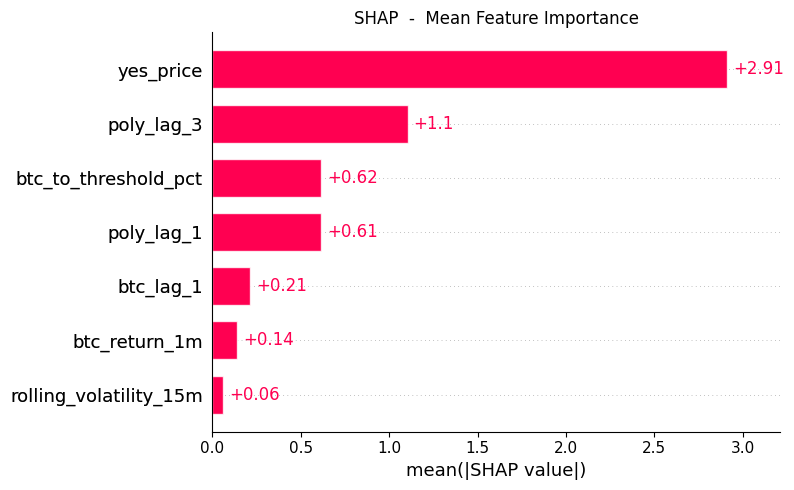

In [12]:
# Beeswarm plot
shap.plots.beeswarm(shap_values, max_display=7, show=False)
plt.title("SHAP  -  Feature Importance (Up class)")
plt.tight_layout()
plt.savefig("data/processed/plot_shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

# Bar plot
shap.plots.bar(shap_values, max_display=7, show=False)
plt.title("SHAP  -  Mean Feature Importance")
plt.tight_layout()
plt.savefig("data/processed/plot_shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()


In [13]:
import subprocess, os
from google.colab import userdata

token = userdata.get("GITHUB_TOKEN")
os.chdir("/content/DSA-Project")

subprocess.run(["git", "config", "user.email", "kadirnsy@gmail.com"])
subprocess.run(["git", "config", "user.name",  "llelus"])
subprocess.run(["git", "pull", "--rebase", "origin", "main"])
subprocess.run(["git", "add", "data/processed/"])
subprocess.run(["git", "commit", "-m", "add: ML outputs  -  confusion matrix, ROC/PR curves, SHAP plots"])
subprocess.run(["git", "push", f"https://{token}@github.com/llelus/DSA-Project.git", "main"])
print("Done.")


Done.
